<a href="https://colab.research.google.com/github/sammywenthikingwithshroomtrolls/Differential-Equation/blob/main/L_14%2C_For_now_I_don't_understand_what_happened_here.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

eigenvalues: [ 3. -1.]
eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
T^-1 A T =
 [[ 3.  0.]
 [ 0. -1.]]
max |exact - numerical| = 6.8265167811887295e-06
recovered slopes: [np.float64(3.0000000419874584), np.float64(-0.9999999996289987)]  (should equal eigenvalues)


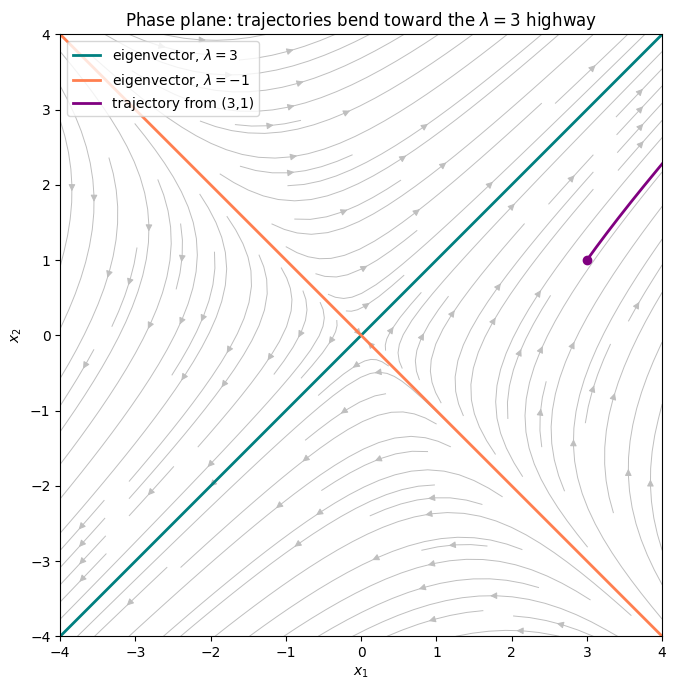

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- The system: x' = A x -----------------------------------------------
A = np.array([[1.0, 2.0],
              [2.0, 1.0]])

# --- Step 1: eigen-decomposition -----------------------------------------
lam, T = np.linalg.eig(A)          # lam = eigenvalues, T columns = eigenvectors
print("eigenvalues:", lam)
print("eigenvectors (columns):\n", T)

# Verify the demand: T^{-1} A T should be diagonal
Lambda = np.linalg.inv(T) @ A @ T
print("T^-1 A T =\n", np.round(Lambda, 10))   # off-diagonals ~ 0

# --- Steps 2-4: closed-form solution vs numerical integration ------------
x0 = np.array([3.0, 1.0])
z0 = np.linalg.inv(T) @ x0                    # step 2: into eigen-coords
t  = np.linspace(0, 1.2, 400)

# step 3+4: x(t) = T @ diag(e^{lam t}) @ z0
x_exact = np.array([T @ (np.exp(lam * ti) * z0) for ti in t]).T

# brute-force numerical solution for comparison
sol = solve_ivp(lambda ti, x: A @ x, (0, 1.2), x0, t_eval=t, rtol=1e-10)
print("max |exact - numerical| =", np.abs(x_exact - sol.y).max())  # ~1e-9

# --- Verify decoupling: z-coordinates of the numerical trajectory --------
z_traj = np.linalg.inv(T) @ sol.y             # should be pure exponentials
# log(z_i) should be a straight line with slope lam_i:
slopes = [np.polyfit(t, np.log(np.abs(z_traj[i])), 1)[0] for i in range(2)]
print("recovered slopes:", slopes, " (should equal eigenvalues)")

# --- Phase portrait -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
g = np.linspace(-4, 4, 21)
X, Y = np.meshgrid(g, g)
U, V = A[0,0]*X + A[0,1]*Y, A[1,0]*X + A[1,1]*Y
ax.streamplot(X, Y, U, V, color='0.75', density=1.2, linewidth=0.7)

for i, c in enumerate(['teal', 'coral']):
    v = T[:, i] / np.abs(T[:, i]).max()
    ax.plot([-4*v[0], 4*v[0]], [-4*v[1], 4*v[1]], c, lw=2,
            label=f'eigenvector, $\\lambda={lam[i]:.0f}$')

ax.plot(*x_exact, 'purple', lw=2, label='trajectory from (3,1)')
ax.plot(*x0, 'o', color='purple')
ax.set(xlim=(-4,4), ylim=(-4,4), xlabel='$x_1$', ylabel='$x_2$',
       title="Phase plane: trajectories bend toward the $\\lambda=3$ highway")
ax.legend(); ax.set_aspect('equal'); plt.tight_layout(); plt.show()